In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    """تثبيت العشوائية لضمان تكرار نفس النتائج (Reproducibility)"""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # لضمان الاستقرار على كروت الشاشة
    
    # الأوامر دي بتجبر PyTorch يستخدم خوارزميات حتمية (Deterministic)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f" Random Seed set to {seed}. Reproducibility Guaranteed!")

# استدعاء الدالة لتأمين الكود
set_seed(42)

 Random Seed set to 42. Reproducibility Guaranteed!


In [2]:
import os
import glob
import scipy.io as sio
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

def extract_windows(emg, label, window_size, step):
    windows, labels = [], []
    for i in range(0, len(emg) - window_size, step):
        window = emg[i:i + window_size]
        win_label = np.bincount(label[i:i + window_size].flatten()).argmax()
        windows.append(window)
        labels.append(win_label)
    return np.array(windows), np.array(labels)

# 🔧 التعديل السحري تم هنا: إضافة معادلات التنظيف الرياضي لكل مريض على حدة
def load_ninapro_task(base_path, allowed_classes, subjects, allowed_reps, train_reps=[1,3,4,6], window_size=200, step=20, num_channels=12, mu=255.0):
    all_x, all_y = [], []
    for subj in subjects:
        search_pattern = os.path.join(base_path, '**', f'S{subj}_E2*.mat')
        file_paths = glob.glob(search_pattern, recursive=True)
        for file_path in file_paths:
            try:
                data = sio.loadmat(file_path)
                emg = data['emg'][:, :num_channels]
                labels = data['restimulus'].flatten()
                reps = data['repetition'].flatten()

                # ==========================================
                # 🛠️ العمليات الرياضية لفك التداخل (Crosstalk)
                # ==========================================
                
                # 1. Full-Wave Rectification (استخراج طاقة العضلة وتوحيد الاتجاه)
                emg = np.abs(emg)
                
                # 2. mu-Law Companding (تضخيم إشارات الأصابع الدقيقة وضغط التشويش العالي)
                emg = np.log1p(mu * emg) / np.log1p(mu)
                
                # 3. Subject-Specific Sensor Normalization (توحيد المقاييس لكل مريض بمفرده)
                # نحسب المتوسط والانحراف من جولات التدريب فقط لمنع تسريب البيانات
                scaler = StandardScaler()
                train_mask = np.isin(reps, train_reps)
                if np.any(train_mask):
                    scaler.fit(emg[train_mask])
                    emg = scaler.transform(emg)
                else:
                    emg = scaler.fit_transform(emg)
                # ==========================================

                unique_reps = np.unique(reps)
                for r in unique_reps:
                    if r not in allowed_reps:
                        continue
                    for c in allowed_classes:
                        segment_mask = (labels == c) & (reps == r)
                        if not np.any(segment_mask):
                            continue
                        segment_emg = emg[segment_mask]
                        segment_label = labels[segment_mask]
                        if len(segment_emg) >= window_size:
                            x_wins, y_wins = extract_windows(segment_emg, segment_label, window_size, step)
                            all_x.append(x_wins)
                            all_y.append(y_wins)
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    if not all_x:
        return np.array([]), np.array([])

    X = np.concatenate(all_x, axis=0)
    Y = np.concatenate(all_y, axis=0).astype(np.int64)
    return X, Y

def balance_classes(X, Y):
    classes, counts = np.unique(Y, return_counts=True)
    print(f"  قبل الموازنة: {dict(zip(classes, counts))}")
    rest_idx = np.where(Y == 0)[0]
    move_idx = np.where(Y != 0)[0]
    if len(move_idx) > 0 and len(rest_idx) > 0:
        target_rest = int(np.mean([c for cls, c in zip(classes, counts) if cls != 0]))
        if len(rest_idx) > target_rest:
            np.random.seed(42)
            sel_rest = np.random.choice(rest_idx, target_rest, replace=False)
            final_idx = np.concatenate([sel_rest, move_idx])
            np.random.shuffle(final_idx)
            X, Y = X[final_idx], Y[final_idx]
            nc, ncounts = np.unique(Y, return_counts=True)
            print(f"  بعد الموازنة: {dict(zip(nc, ncounts))}")
    return X, Y

# ==========================================
# إعدادات المسارات وتقسيم المرضى
# ==========================================
TRAIN_DIR = '/kaggle/input/datasets/farahellabban/ninapro-db2'
TARGET_DIR = '/kaggle/input/datasets/farahellabban/ninapro-db2'

PRETRAIN_SUBJECTS = [1, 2, 3, 4]
TARGET_SUBJECT = [5]

# ==========================================
# 1. بيانات الـ Pretrain: المرضى الـ 4 الأوائل
# ==========================================
print("\nLoading Pretrain Data (4 subjects, 12 classes from E2)...")
e2_all_classes = [0] + list(range(18, 29)) 

X_pre_train, Y_pre_train = load_ninapro_task(TRAIN_DIR, e2_all_classes, PRETRAIN_SUBJECTS, [1,3,4,6], num_channels=12)
X_pre_val,   Y_pre_val   = load_ninapro_task(TRAIN_DIR, e2_all_classes, PRETRAIN_SUBJECTS, [2,5], num_channels=12)

X_pre_train, Y_pre_train = balance_classes(X_pre_train, Y_pre_train)
X_pre_val,   Y_pre_val   = balance_classes(X_pre_val, Y_pre_val)

def make_loader(X, Y, batch_size=64, shuffle=True):
    # لاحظي: البيانات أصبحت نظيفة وموحدة مسبقاً، نرسلها مباشرة للـ Tensor
    return DataLoader(TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(Y)), batch_size=batch_size, shuffle=shuffle)

pretrain_loader = make_loader(X_pre_train, Y_pre_train)
pretrain_val_loader = make_loader(X_pre_val, Y_pre_val, shuffle=False)

# ==========================================
# 2. بيانات المريض الخامس (Subject 5)
# ==========================================
print("\nLoading Subject 5 - Task 1 (Base Classes: 0 and 18 to 24)...")
task1_classes = [0, 18, 19, 20, 21, 22, 23, 24]
X_t1_train, Y_t1_train = load_ninapro_task(TARGET_DIR, task1_classes, TARGET_SUBJECT, [1,3,4,6], step=10, num_channels=12)
X_t1_test,  Y_t1_test  = load_ninapro_task(TARGET_DIR, task1_classes, TARGET_SUBJECT, [2,5], step=10, num_channels=12)

print("Loading Subject 5 - Task 2 (Novel Classes: 0 and 25 to 28)...")
task2_classes = [0, 25, 26, 27, 28]
X_t2_train, Y_t2_train = load_ninapro_task(TARGET_DIR, task2_classes, TARGET_SUBJECT, [1,3,4,6], step=10, num_channels=12)
X_t2_test,  Y_t2_test  = load_ninapro_task(TARGET_DIR, task2_classes, TARGET_SUBJECT, [2,5], step=10, num_channels=12)

X_t1_train, Y_t1_train = balance_classes(X_t1_train, Y_t1_train)
X_t2_train, Y_t2_train = balance_classes(X_t2_train, Y_t2_train)

t1_train_loader = make_loader(X_t1_train, Y_t1_train)
t1_test_loader  = make_loader(X_t1_test, Y_t1_test, shuffle=False)
t2_train_loader = make_loader(X_t2_train, Y_t2_train)
t2_test_loader  = make_loader(X_t2_test, Y_t2_test, shuffle=False)


Loading Pretrain Data (4 subjects, 12 classes from E2)...
  قبل الموازنة: {np.int64(0): np.int64(33898), np.int64(18): np.int64(6969), np.int64(19): np.int64(6302), np.int64(20): np.int64(6749), np.int64(21): np.int64(5895), np.int64(22): np.int64(7025), np.int64(23): np.int64(6827), np.int64(24): np.int64(8034), np.int64(25): np.int64(7217), np.int64(26): np.int64(7897), np.int64(27): np.int64(6234), np.int64(28): np.int64(7035)}
  بعد الموازنة: {np.int64(0): np.int64(6925), np.int64(18): np.int64(6969), np.int64(19): np.int64(6302), np.int64(20): np.int64(6749), np.int64(21): np.int64(5895), np.int64(22): np.int64(7025), np.int64(23): np.int64(6827), np.int64(24): np.int64(8034), np.int64(25): np.int64(7217), np.int64(26): np.int64(7897), np.int64(27): np.int64(6234), np.int64(28): np.int64(7035)}
  قبل الموازنة: {np.int64(0): np.int64(15644), np.int64(18): np.int64(3627), np.int64(19): np.int64(3244), np.int64(20): np.int64(3228), np.int64(21): np.int64(3285), np.int64(22): np.int6

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=8):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc1 = nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False)
        self.relu = nn.ReLU()
        self.fc2 = nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc2(self.relu(self.fc1(self.avg_pool(x))))
        max_out = self.fc2(self.relu(self.fc1(self.max_pool(x))))
        out = avg_out + max_out
        return self.sigmoid(out) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, 3, padding=1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out) * x

class TemporalAttention(nn.Module):
    def __init__(self, hidden_size):
        super(TemporalAttention, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, gru_output):
        attention_weights = self.attention(gru_output)
        attention_weights = F.softmax(attention_weights, dim=1)
        context_vector = torch.sum(attention_weights * gru_output, dim=1)
        return context_vector

# =====================================================================
#  المعمارية المحدثة (تحتوي على proj_dim=128)
# =====================================================================
class Metric_ContinualNet(nn.Module):
    # لاحظي وجود proj_dim هنا
    def __init__(self, embedding_dim=32, proj_dim=128, num_sensors=12, window_size=200):
        super(Metric_ContinualNet, self).__init__()
        
        self.temporal_filter = nn.Conv2d(1, 16, kernel_size=(1, 15), stride=(1, 2), padding=(0, 7))
        self.bn_temp = nn.BatchNorm2d(16)
        
        self.depthwise = nn.Conv2d(16, 32, kernel_size=(3, 3), padding=0, groups=16)
        self.pointwise = nn.Conv2d(32, 32, kernel_size=1)
        self.bn_spat = nn.BatchNorm2d(32)
        
        self.ca = ChannelAttention(32)
        self.sa = SpatialAttention()
        
        self.pool = nn.MaxPool2d(kernel_size=(2, 4))
        self.dropout = nn.Dropout(0.4) 
        
        s_new = num_sensors // 2 
        gru_input_dim = 32 * s_new 
        
        self.gru = nn.GRU(
            input_size=gru_input_dim, 
            hidden_size=128,  
            num_layers=2, 
            batch_first=True,
            dropout=0.4
        )
        self.temporal_attention = TemporalAttention(128)
        
        self.embedding_head = nn.Sequential(
            nn.Linear(128, 64), 
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, embedding_dim) 
        )

        self.projection_head = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, proj_dim) 
        )

        self.metric_scale = nn.Parameter(torch.tensor(10.0))
        
        self.regression_head = nn.Sequential(
            nn.Linear(128, 32), 
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, W, S = x.shape
        x = x.permute(0, 2, 1).contiguous()
        x = x.unsqueeze(1)
        
        x = F.relu(self.bn_temp(self.temporal_filter(x)))
        x = F.pad(x, (1, 1, 0, 0), mode='constant', value=0) 
        x = F.pad(x, (0, 0, 1, 1), mode='circular')          
        
        x = self.depthwise(x)
        x = F.relu(self.bn_spat(self.pointwise(x)))
        x = self.ca(x)
        x = self.sa(x)
        
        x = self.pool(x)
        x = self.dropout(x)
        
        B, C, S_new, T_new = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()
        x = x.view(B, T_new, C * S_new)
        
        gru_out, _ = self.gru(x)
        features = self.temporal_attention(gru_out)
        
        base_embeddings = self.embedding_head(features)
        proj_embeddings = self.projection_head(base_embeddings)
        
        base_embeddings = F.normalize(base_embeddings, p=2, dim=1) * self.metric_scale
        proj_embeddings = F.normalize(proj_embeddings, p=2, dim=1) * self.metric_scale
        
        force = self.regression_head(features)
        
        # يُخرج الـ 3 متغيرات
        return proj_embeddings, base_embeddings, force

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.1): 
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        device = features.device
        features = F.normalize(features, p=2, dim=1)
        batch_size = features.shape[0]
        labels = labels.contiguous().view(-1, 1)
        
        mask = torch.eq(labels, labels.T).float().to(device)
        anchor_dot_contrast = torch.div(
            torch.matmul(features, features.T),
            self.temperature
        )
        
        logits_max, _ = torch.max(anchor_dot_contrast, dim=1, keepdim=True)
        logits = anchor_dot_contrast - logits_max.detach()
        
        logits_mask = torch.scatter(
            torch.ones_like(mask), 1, torch.arange(batch_size, device=device).view(-1, 1), 0
        )
        mask = mask * logits_mask
        
        exp_logits = torch.exp(logits) * logits_mask
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + 1e-9)
        
        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + 1e-9)
        loss = -mean_log_prob_pos
        valid_mask = (mask.sum(1) > 0)
        
        return loss[valid_mask].mean() if valid_mask.sum() > 0 else loss.mean()

def train_supcon_phase1(model, train_loader, val_loader, epochs=70, lr=0.001, device='cuda'):
    criterion = SupConLoss(temperature=0.1)
    # التعديل الأول: رفع الـ weight_decay من 1e-4 إلى 1e-2 لمنع الحفظ
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    print("\n🚀 [Phase 1] Starting Training with Noise Injection & High L2 Penalty...")
    
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # ==========================================
        # 1. Training Phase
        # ==========================================
        model.train()
        running_train_loss = 0.0
        train_samples = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # التعديل الثاني: حقن ضوضاء عشوائية بنسبة 5% أثناء التدريب فقط
            noise = torch.randn_like(inputs) * 0.05
            noisy_inputs = inputs + noise
            
            optimizer.zero_grad()
            
            # نمرر البيانات المشوشة للموديل
            proj_emb, base_emb, _ = model(noisy_inputs)
            loss = criterion(proj_emb, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            running_train_loss += loss.item() * inputs.size(0)
            train_samples += inputs.size(0)
            
        epoch_train_loss = running_train_loss / max(1, train_samples)
        
        # ==========================================
        # 2. Validation Phase (Loss & Accuracy)
        # ==========================================
        model.eval()
        running_val_loss = 0.0
        val_samples = 0
        
        val_embeddings_list = []
        val_labels_list = []
        
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs, val_labels = val_inputs.to(device), val_labels.to(device)
                
                # التحقق يتم على البيانات النظيفة (بدون ضوضاء)
                proj_emb, base_emb, _ = model(val_inputs)
                
                v_loss = criterion(proj_emb, val_labels)
                running_val_loss += v_loss.item() * val_inputs.size(0)
                val_samples += val_inputs.size(0)
                
                val_embeddings_list.append(base_emb.cpu())
                val_labels_list.append(val_labels.cpu())
                
        epoch_val_loss = running_val_loss / max(1, val_samples)
        
        val_accuracy = 0.0
        if len(val_embeddings_list) > 0:
            all_val_embs = torch.cat(val_embeddings_list, dim=0)
            all_val_labels = torch.cat(val_labels_list, dim=0)
            
            class_protos = {}
            for lbl in torch.unique(all_val_labels):
                mask = (all_val_labels == lbl)
                class_protos[lbl.item()] = all_val_embs[mask].mean(dim=0)
                
            proto_keys = sorted(class_protos.keys())
            proto_tensor = torch.stack([class_protos[k] for k in proto_keys]).to(device)
            proto_tensor = F.normalize(proto_tensor, p=2, dim=1)
            
            correct = 0
            total = 0
            for i in range(0, len(all_val_embs), 256):
                batch_embs = all_val_embs[i:i+256].to(device)
                batch_labels = all_val_labels[i:i+256].to(device)
                
                batch_embs_norm = F.normalize(batch_embs, p=2, dim=1)
                distances = torch.cdist(batch_embs_norm, proto_tensor, p=2)
                preds_idx = distances.argmin(dim=1)
                preds = torch.tensor([proto_keys[idx] for idx in preds_idx], device=device)
                
                correct += (preds == batch_labels).sum().item()
                total += batch_labels.size(0)
                
            val_accuracy = (correct / total) * 100 if total > 0 else 0.0
            
        scheduler.step(epoch_val_loss)
        
        marker = " (New High!)" if val_accuracy > best_val_acc else ""
        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            
        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} |  Val Acc: {val_accuracy:.2f}% {marker}")
        
    print(f"\n Phase 1 Completed! Best Validation Accuracy: {best_val_acc:.2f}%")
    return model

# ==========================================
# التنفيذ الموسع للمرحلة الأولى (تمت إضافته هنا)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. إعادة تعريف الموديل لمسح الأوزان القديمة (منع الـ Overfitting القديم من التأثير)
metric_model = Metric_ContinualNet(embedding_dim=32, proj_dim=128, num_sensors=12).to(device)

# 2. تشغيل التدريب
metric_model = train_supcon_phase1(
    metric_model, 
    pretrain_loader,      
    pretrain_val_loader,  
    epochs=70, 
    lr=0.001, 
    device=device
)


🚀 [Phase 1] Starting Training with Noise Injection & High L2 Penalty...
Epoch [01/70] | Train Loss: 3.9152 | Val Loss: 3.8028 |  Val Acc: 36.47%  (New High!)
Epoch [02/70] | Train Loss: 3.7485 | Val Loss: 3.6852 |  Val Acc: 42.48%  (New High!)
Epoch [03/70] | Train Loss: 3.6051 | Val Loss: 3.5836 |  Val Acc: 49.94%  (New High!)
Epoch [04/70] | Train Loss: 3.4574 | Val Loss: 3.5130 |  Val Acc: 54.19%  (New High!)
Epoch [05/70] | Train Loss: 3.3201 | Val Loss: 3.5134 |  Val Acc: 55.27%  (New High!)
Epoch [06/70] | Train Loss: 3.2072 | Val Loss: 3.4828 |  Val Acc: 57.66%  (New High!)
Epoch [07/70] | Train Loss: 3.1086 | Val Loss: 3.4928 |  Val Acc: 57.55% 
Epoch [08/70] | Train Loss: 3.0268 | Val Loss: 3.4796 |  Val Acc: 59.45%  (New High!)
Epoch [09/70] | Train Loss: 2.9397 | Val Loss: 3.5417 |  Val Acc: 59.22% 
Epoch [10/70] | Train Loss: 2.8804 | Val Loss: 3.4844 |  Val Acc: 60.58%  (New High!)
Epoch [11/70] | Train Loss: 2.8222 | Val Loss: 3.5148 |  Val Acc: 60.07% 
Epoch [12/70] | T

In [11]:
import torch
import torch.nn.functional as F


def compute_class_prototypes(model, dataloader, device='cuda'):
    """
    Calculates the prototype (mean embedding) for each class dynamically.
    This acts as the 'center' for each movement in the metric space.
    """
    model.eval()
    
    # قاموس فارغ هيتملي أوتوماتيك بأرقام الحركات اللي هيلاقيها في الداتا
    class_embeddings = {}
    
    print(" Extracting embeddings to compute prototypes...")
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            embeddings, _ = model(inputs)
            
            for i in range(len(labels)):
                label = labels[i].item()
                
                # لو رقم الحركة ده جديد (مثلاً 18 أو 19)، افتحله لستة جديدة في القاموس
                if label not in class_embeddings:
                    class_embeddings[label] = []
                    
                class_embeddings[label].append(embeddings[i].cpu())
                
    prototypes = {}
    for label, embs in class_embeddings.items():
        if len(embs) > 0:
            stacked_embs = torch.stack(embs)
            proto_mean = stacked_embs.mean(dim=0)
            proto_normalized = F.normalize(proto_mean.unsqueeze(0), p=2, dim=1).squeeze(0)
            
            prototypes[label] = proto_normalized.to(device)
            print(f" Prototype for Class {label} computed successfully. (Shape: {proto_normalized.shape})")
            
    return prototypes

# ==========================================
# Execute Prototype Computation using Training Data (Task 1)
# ==========================================
print(" Starting Prototype Extraction Phase for Task 1...")

# استدعاء الدالة بدون ما نحدد عدد كلاسات، هي هتعرف لوحدها إنهم 8 حركات وتعملهم
movement_prototypes = compute_class_prototypes(metric_model, t1_train_loader, device=device)

 Starting Prototype Extraction Phase for Task 1...
 Extracting embeddings to compute prototypes...
 Prototype for Class 18 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 24 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 19 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 23 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 0 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 21 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 20 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 22 computed successfully. (Shape: torch.Size([32]))


In [12]:
import torch

def distance_based_inference(model, dataloader, prototypes, threshold=0.8, device='cuda'):
    """
    Distance-Based Inference (Safe Rejection V2):
    Classifies incoming signals based on their distance to the known prototypes.
    """
    model.eval()
    total_samples = 0
    accepted_samples = 0
    rejected_samples = 0
    correct_predictions = 0
    
    # 🔧 التعديل الأول: سحب وترتيب الأرقام الحقيقية للحركات من القاموس
    sorted_keys = sorted(prototypes.keys())
    # بناء مصفوفة الـ Tensor بناءً على المفاتيح الحقيقية عشان نتجنب الـ KeyError
    proto_tensor = torch.stack([prototypes[k] for k in sorted_keys]).to(device)
    
    print(f"\n --- Metric Safe Rejection Activated (Distance Threshold: {threshold}) --- \n")
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            
            # 1. Extract embedding and force
            embeddings, force = model(x)
            
            # 2. Calculate Euclidean distance between the batch and all prototypes
            distances = torch.cdist(embeddings, proto_tensor, p=2.0)
            
            # 3. Find the closest prototype (minimum distance)
            # predicted_indices هنا بتطلع الـ Index (من 0 لـ 7) مش رقم الحركة
            min_distances, predicted_indices = torch.min(distances, dim=1)
            
            for i in range(len(min_distances)):
                total_samples += 1
                dist = min_distances[i].item()
                
                # 🔧 التعديل الثاني: تحويل الـ Index لرقم الحركة الحقيقي (مثلاً إندكس 1 = حركة 18)
                pred_class = sorted_keys[predicted_indices[i].item()]
                true_class = y[i].item()
                f_val = force[i].item()
                
                # 4. Apply Distance Threshold for Rejection
                if dist > threshold:
                    rejected_samples += 1
                    if rejected_samples <= 5:
                        print(f" Sample {total_samples}: Rejected! (Distance: {dist:.3f} > {threshold}) -> Forcing Rest (0). Estimated Force: {f_val:.2f}")
                else:
                    accepted_samples += 1
                    if pred_class == true_class:
                        correct_predictions += 1
                        
                    if accepted_samples <= 5:
                        print(f" Sample {total_samples}: Accepted. (Class: {pred_class} | Distance: {dist:.3f}) -> Motor Force: {f_val:.2f}")
                        
    # 5. Statistical Summary
    print("\n" + "="*55)
    print(" Metric Learning Performance & Safety Summary:")
    print("="*55)
    print(f"Total Tested Samples: {total_samples}")
    if total_samples > 0:
        print(f"Accepted Movements: {accepted_samples} ({(accepted_samples/total_samples)*100:.1f}%)")
        print(f"Rejected Movements (Unknown/Outliers): {rejected_samples} ({(rejected_samples/total_samples)*100:.1f}%)")
    
    if accepted_samples > 0:
        acc = (correct_predictions / accepted_samples) * 100
        print(f"Accuracy on Accepted Movements: {acc:.2f}%")
    print("="*55)

# ==========================================
# Execute on Task 1 Test Data
# ==========================================
distance_based_inference(metric_model, t1_test_loader, movement_prototypes, threshold=0.8, device=device)


 --- Metric Safe Rejection Activated (Distance Threshold: 0.8) --- 

 Sample 1: Accepted. (Class: 0 | Distance: 0.382) -> Motor Force: 0.11
 Sample 2: Accepted. (Class: 0 | Distance: 0.430) -> Motor Force: 0.12
 Sample 3: Accepted. (Class: 0 | Distance: 0.275) -> Motor Force: 0.13
 Sample 4: Accepted. (Class: 0 | Distance: 0.130) -> Motor Force: 0.14
 Sample 5: Accepted. (Class: 0 | Distance: 0.035) -> Motor Force: 0.15
 Sample 20: Rejected! (Distance: 0.806 > 0.8) -> Forcing Rest (0). Estimated Force: 0.17
 Sample 568: Rejected! (Distance: 0.813 > 0.8) -> Forcing Rest (0). Estimated Force: 0.16
 Sample 569: Rejected! (Distance: 0.862 > 0.8) -> Forcing Rest (0). Estimated Force: 0.17
 Sample 615: Rejected! (Distance: 0.859 > 0.8) -> Forcing Rest (0). Estimated Force: 0.16
 Sample 616: Rejected! (Distance: 0.879 > 0.8) -> Forcing Rest (0). Estimated Force: 0.18

 Metric Learning Performance & Safety Summary:
Total Tested Samples: 26796
Accepted Movements: 23300 (87.0%)
Rejected Movemen

 Extracting Prototypes for Task 2 (Classes 25, 26, 27, 28)...
 Extracting embeddings to compute prototypes...
 Prototype for Class 27 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 0 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 25 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 28 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 26 computed successfully. (Shape: torch.Size([32]))
 Added Prototype for Class 25 to the global metric space.
 Added Prototype for Class 26 to the global metric space.
 Added Prototype for Class 27 to the global metric space.
 Added Prototype for Class 28 to the global metric space.

 Running distance-based inference on ALL test data...


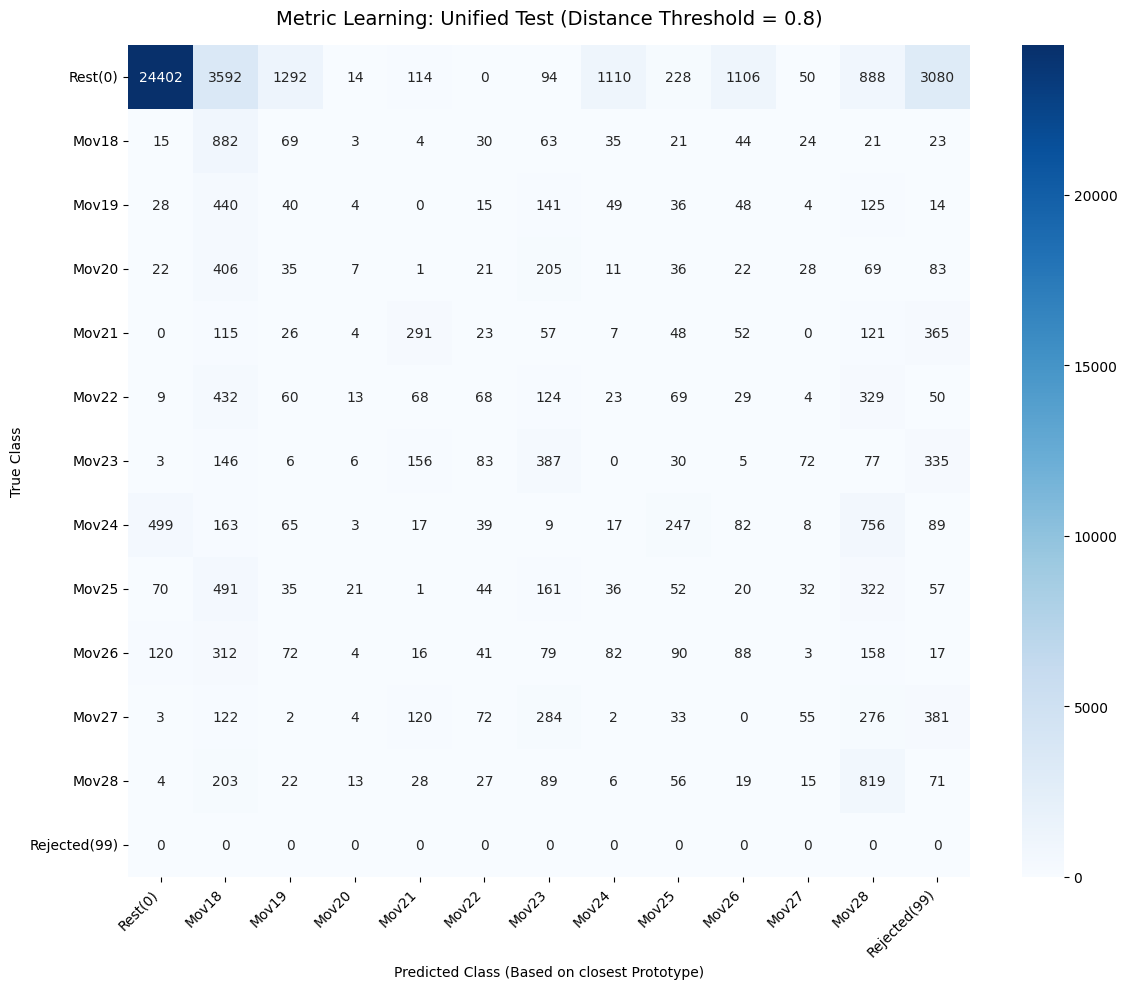


Classification Report (Including Rejected Samples as class '99')
              precision    recall  f1-score   support

     Rest(0)       0.97      0.68      0.80     35970
       Mov18       0.12      0.71      0.21      1234
       Mov19       0.02      0.04      0.03       944
       Mov20       0.07      0.01      0.01       946
       Mov21       0.36      0.26      0.30      1109
       Mov22       0.15      0.05      0.08      1278
       Mov23       0.23      0.30      0.26      1306
       Mov24       0.01      0.01      0.01      1994
       Mov25       0.05      0.04      0.05      1342
       Mov26       0.06      0.08      0.07      1082
       Mov27       0.19      0.04      0.07      1354
       Mov28       0.21      0.60      0.31      1372
Rejected(99)       0.00      0.00      0.00         0

    accuracy                           0.54     49931
   macro avg       0.19      0.22      0.17     49931
weighted avg       0.73      0.54      0.61     49931



In [13]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import ConcatDataset, DataLoader
import numpy as np

# ==========================================
# 1. Live Few-Shot Learning (Extracting Task 2 Prototypes instantly)
# ==========================================
print(" Extracting Prototypes for Task 2 (Classes 25, 26, 27, 28)...")
# 🔧 التعديل 1: مسحنا num_classes واستخدمنا الدالة الديناميكية
task2_prototypes_raw = compute_class_prototypes(metric_model, t2_train_loader, device=device)

# Merge Task 2 new prototypes with Task 1 existing prototypes
all_prototypes = movement_prototypes.copy()

# 🔧 التعديل 2: الحركات الجديدة الخاصة بـ Task 2 هي 25, 26, 27, 28
for cls in [25, 26, 27, 28]:
    if cls in task2_prototypes_raw and task2_prototypes_raw[cls] is not None:
        all_prototypes[cls] = task2_prototypes_raw[cls]
        print(f" Added Prototype for Class {cls} to the global metric space.")

# ==========================================
# 2. Unified Evaluation Function with Confusion Matrix
# ==========================================
def evaluate_metric_all_tasks(model, loader_t1, loader_t2, prototypes, threshold=0.8, device='cuda'):
    model.eval()
    all_preds = []
    all_labels = []
    
    # Create a unified test dataloader
    combined_dataset = ConcatDataset([loader_t1.dataset, loader_t2.dataset])
    combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=False)
    
    # 🔧 التعديل 3: سحب وترتيب المفاتيح لتجنب KeyError
    sorted_keys = sorted(prototypes.keys())
    proto_tensor = torch.stack([prototypes[k] for k in sorted_keys]).to(device)
    
    print("\n Running distance-based inference on ALL test data...")
    with torch.no_grad():
        for x, y in combined_loader:
            x = x.to(device)
            y = y.to(device)
            
            embeddings, _ = model(x)
            distances = torch.cdist(embeddings, proto_tensor, p=2.0)
            min_distances, predicted_indices = torch.min(distances, dim=1)
            
            for i in range(len(min_distances)):
                dist = min_distances[i].item()
                true_class = y[i].item()
                
                # 🔧 التعديل 4: تحويل الإندكس لرقم الكلاس الحقيقي
                pred_class = sorted_keys[predicted_indices[i].item()]
                
                all_labels.append(true_class)
                
                # 🔧 التعديل 5: استخدام 99 كرمز للحركات المرفوضة بدل 6
                if dist > threshold:
                    all_preds.append(99)
                else:
                    all_preds.append(pred_class)

    # ==========================================
    # 3. Plotting the Confusion Matrix
    # ==========================================
    # 🔧 التعديل 6: تحديث أرقام وأسماء الحركات لتناسب جميع الحركات من 18 لـ 28
    actual_classes = [0, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 99]
    class_names = ['Rest(0)'] + [f'Mov{i}' for i in range(18, 29)] + ['Rejected(99)']
    
    cm = confusion_matrix(all_labels, all_preds, labels=actual_classes)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Metric Learning: Unified Test (Distance Threshold = {threshold})", fontsize=14, pad=15)
    plt.xlabel('Predicted Class (Based on closest Prototype)')
    plt.ylabel('True Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("Classification Report (Including Rejected Samples as class '99')")
    print("="*60)
    print(classification_report(all_labels, all_preds, labels=actual_classes,
                                target_names=class_names, zero_division=0))

# Execute the comprehensive test
evaluate_metric_all_tasks(metric_model, t1_test_loader, t2_test_loader, all_prototypes, threshold=0.8, device=device)

In [14]:
import torch
from torch.utils.data import DataLoader, Subset, ConcatDataset

def split_base_novel_datasets(full_dataset, base_classes, novel_classes):
    """
    Splits a full PyTorch Dataset into Base and Novel subsets based on class labels.
    - Base: Used for training the feature extractor (backbone).
    - Novel: Used for testing Few-Shot Learning capabilities.
    """
    base_indices = []
    novel_indices = []
    
    print(" Scanning dataset for Base and Novel class distribution...")
    for i in range(len(full_dataset)):
        _, label = full_dataset[i]
        label = int(label.item() if torch.is_tensor(label) else label)
        
        if label in base_classes:
            base_indices.append(i)
        elif label in novel_classes:
            novel_indices.append(i)
            
    base_dataset = Subset(full_dataset, base_indices)
    novel_dataset = Subset(full_dataset, novel_indices)
    
    print(f" Base Dataset (Classes {base_classes}): {len(base_dataset)} samples")
    print(f" Novel Dataset (Classes {novel_classes}): {len(novel_dataset)} samples")
    
    return base_dataset, novel_dataset

# ==========================================
# Defining Class Splits (مطابقة لـ E2)
# ==========================================
# الحركات الأساسية (Task 1)
BASE_CLASSES = [0, 18, 19, 20, 21, 22, 23, 24]

# الحركات الجديدة للـ Few-Shot (Task 2)
NOVEL_CLASSES = [25, 26, 27, 28]

# تجميع بيانات التدريب والاختبار
full_train_dataset = ConcatDataset([t1_train_loader.dataset, t2_train_loader.dataset])
full_test_dataset = ConcatDataset([t1_test_loader.dataset, t2_test_loader.dataset])

# Create Subsets
base_train_ds, novel_train_ds = split_base_novel_datasets(full_train_dataset, BASE_CLASSES, NOVEL_CLASSES)
base_test_ds, novel_test_ds = split_base_novel_datasets(full_test_dataset, BASE_CLASSES, NOVEL_CLASSES)

# Create DataLoaders
BATCH_SIZE = 64
base_train_loader = DataLoader(base_train_ds, batch_size=BATCH_SIZE, shuffle=True)
base_test_loader = DataLoader(base_test_ds, batch_size=BATCH_SIZE, shuffle=False)

# novel_train_loader يُستخدم فقط لاستخراج البصمات (Few-Shot) وليس للتدريب العكسي
novel_train_loader = DataLoader(novel_train_ds, batch_size=BATCH_SIZE, shuffle=False)
novel_test_loader = DataLoader(novel_test_ds, batch_size=BATCH_SIZE, shuffle=False)

 Scanning dataset for Base and Novel class distribution...
 Base Dataset (Classes [0, 18, 19, 20, 21, 22, 23, 24]): 24836 samples
 Novel Dataset (Classes [25, 26, 27, 28]): 10482 samples
 Scanning dataset for Base and Novel class distribution...
 Base Dataset (Classes [0, 18, 19, 20, 21, 22, 23, 24]): 44781 samples
 Novel Dataset (Classes [25, 26, 27, 28]): 5150 samples


In [15]:
# ==========================================
# Base Training Phase
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize a fresh model
meta_metric_model = Metric_ContinualNet(embedding_dim=32).to(device)

print(" Starting Meta-Learning Phase: Training Backbone on Base Classes...")
# We use the train_metric_learning function we defined earlier
meta_metric_model = train_metric_learning(
    meta_metric_model, 
    base_train_loader, 
    base_test_loader, 
    epochs=20, 
    lr=0.001, 
    device=device
)

 Starting Meta-Learning Phase: Training Backbone on Base Classes...
Epoch [01/20] | Metric Training Loss: 0.5073
Epoch [02/20] | Metric Training Loss: 0.3751
Epoch [03/20] | Metric Training Loss: 0.3271
Epoch [04/20] | Metric Training Loss: 0.2903
Epoch [05/20] | Metric Training Loss: 0.2656
Epoch [06/20] | Metric Training Loss: 0.2575
Epoch [07/20] | Metric Training Loss: 0.2335
Epoch [08/20] | Metric Training Loss: 0.2187
Epoch [09/20] | Metric Training Loss: 0.2111
Epoch [10/20] | Metric Training Loss: 0.2159
Epoch [11/20] | Metric Training Loss: 0.1916
Epoch [12/20] | Metric Training Loss: 0.1911
Epoch [13/20] | Metric Training Loss: 0.1725
Epoch [14/20] | Metric Training Loss: 0.1829
Epoch [15/20] | Metric Training Loss: 0.1666
Epoch [16/20] | Metric Training Loss: 0.1532
Epoch [17/20] | Metric Training Loss: 0.1513
Epoch [18/20] | Metric Training Loss: 0.1529
Epoch [19/20] | Metric Training Loss: 0.1444
Epoch [20/20] | Metric Training Loss: 0.1341



 Extracting Prototypes for BASE Classes...
 Extracting embeddings to compute prototypes...
 Prototype for Class 24 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 19 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 23 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 0 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 20 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 21 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 18 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 22 computed successfully. (Shape: torch.Size([32]))

 Extracting Prototypes for NOVEL Classes instantly...
 Extracting embeddings to compute prototypes...
 Prototype for Class 27 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 25 computed successfully. (Shape: torch.Size([32]))
 Prototype for Class 28 computed successfully. (Shape: torch.Size([32]))
 Pr

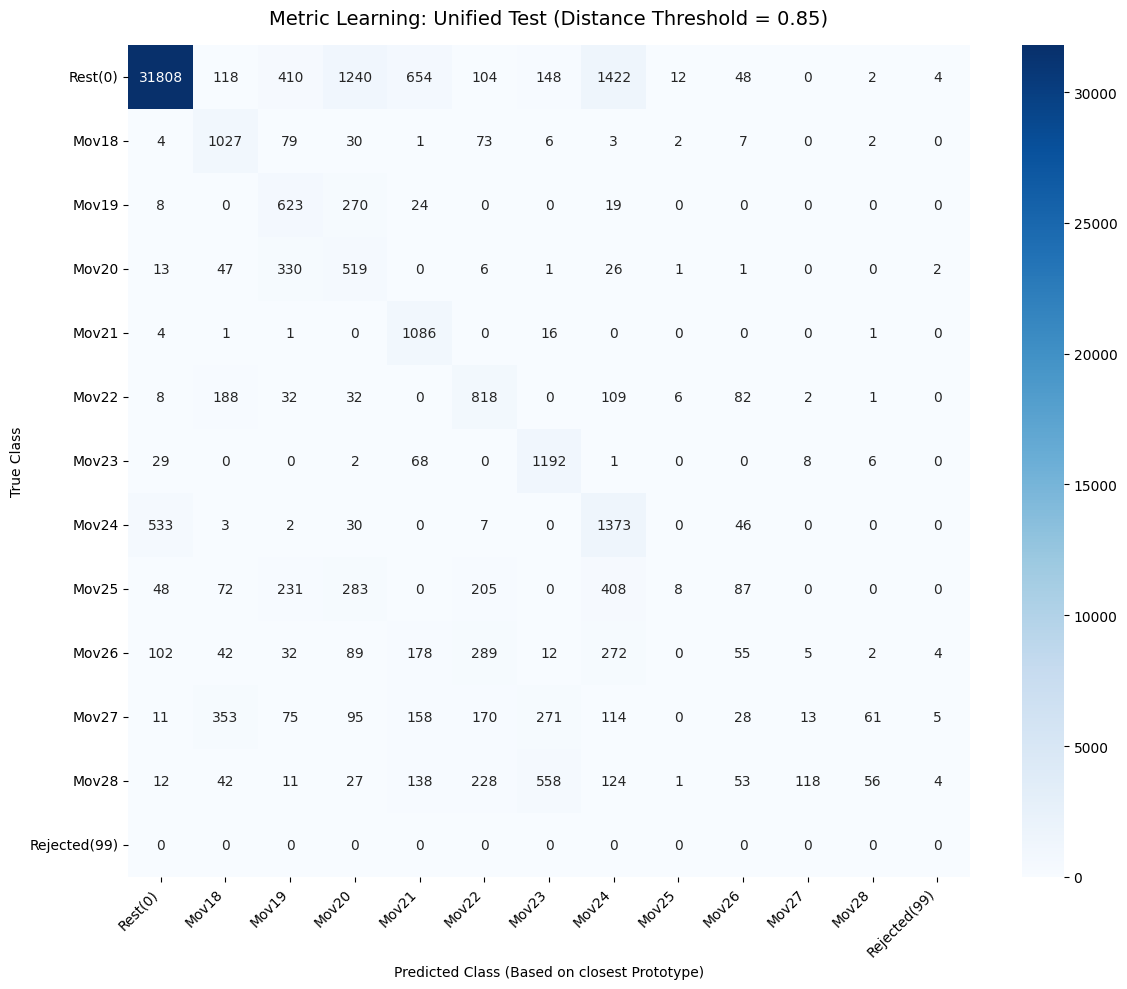


Classification Report (Including Rejected Samples as class '99')
              precision    recall  f1-score   support

     Rest(0)       0.98      0.88      0.93     35970
       Mov18       0.54      0.83      0.66      1234
       Mov19       0.34      0.66      0.45       944
       Mov20       0.20      0.55      0.29       946
       Mov21       0.47      0.98      0.64      1109
       Mov22       0.43      0.64      0.51      1278
       Mov23       0.54      0.91      0.68      1306
       Mov24       0.35      0.69      0.47      1994
       Mov25       0.27      0.01      0.01      1342
       Mov26       0.14      0.05      0.07      1082
       Mov27       0.09      0.01      0.02      1354
       Mov28       0.43      0.04      0.07      1372
Rejected(99)       0.00      0.00      0.00         0

    accuracy                           0.77     49931
   macro avg       0.37      0.48      0.37     49931
weighted avg       0.80      0.77      0.77     49931



In [16]:
# ==========================================
# Prototype Extraction (Live Few-Shot Learning)
# ==========================================
print("\n Extracting Prototypes for BASE Classes...")
# شلنا num_classes عشان تشتغل ديناميكياً مع حركات Base
base_prototypes = compute_class_prototypes(meta_metric_model, base_train_loader, device=device)

print("\n Extracting Prototypes for NOVEL Classes instantly...")
# شلنا num_classes عشان تشتغل ديناميكياً مع حركات Novel
novel_prototypes = compute_class_prototypes(meta_metric_model, novel_train_loader, device=device)

# Merge all prototypes into one global dictionary (دمج ديناميكي وسريع)
global_prototypes = {**base_prototypes, **novel_prototypes}
print(f" Total Prototypes Extracted for classes: {list(global_prototypes.keys())}")

# ==========================================
# Comprehensive Evaluation
# ==========================================
print("\n Running distance-based inference on ALL test data (Base + Novel)...")
evaluate_metric_all_tasks(
    meta_metric_model, 
    base_test_loader, 
    novel_test_loader, 
    global_prototypes, 
    threshold=0.85, # عتبة أمان مناسبة للمساحة الكبيرة
    device=device
)

In [11]:
import torch

class StreamingLDA:
    def __init__(self, input_dim=32, shrinkage_param=1e-4, device='cuda'):
        """
        Streaming Linear Discriminant Analysis (SLDA).
        Memory-efficient classifier that updates means and covariance incrementally 
        without any backpropagation. Ideal for Edge AI.
        """
        self.input_dim = input_dim
        self.shrinkage_param = shrinkage_param
        self.device = device
        
        # Dynamic dictionaries to handle incremental class additions
        self.class_means = {}
        self.class_counts = {}
        
        # Scatter matrix (unnormalized covariance matrix)
        self.scatter_matrix = torch.zeros((input_dim, input_dim)).to(device)
        self.total_samples = 0
        
        # Inverted covariance (Precision matrix) cached for fast inference
        self.precision_matrix = None

    def _update_scatter(self, features, labels):
        unique_classes = torch.unique(labels)
        
        for c in unique_classes:
            c = c.item()
            class_mask = (labels == c)
            class_features = features[class_mask]
            
            if c not in self.class_means:
                self.class_means[c] = torch.zeros(self.input_dim).to(self.device)
                self.class_counts[c] = 0
            
            old_count = self.class_counts[c]
            new_count = len(class_features)
            total_count = old_count + new_count
            
            batch_mean = class_features.mean(dim=0)
            
            # 1. Update scatter matrix (Covariance calculation)
            centered_features = class_features - batch_mean
            self.scatter_matrix += torch.matmul(centered_features.T, centered_features)
            
            # 2. Streaming update for the class mean
            self.class_means[c] = (self.class_means[c] * old_count + batch_mean * new_count) / total_count
            self.class_counts[c] = total_count
            self.total_samples += new_count
            
        self._compute_precision_matrix()

    def _compute_precision_matrix(self):
        k = len(self.class_means)
        if k == 0 or self.total_samples <= k:
            return
            
        # Normalize scatter to get actual covariance
        covariance = self.scatter_matrix / (self.total_samples - k)
            
        # Apply Shrinkage to ensure the matrix is invertible (Numerical stability)
        identity = torch.eye(self.input_dim).to(self.device)
        cov_shrunk = (1 - self.shrinkage_param) * covariance + self.shrinkage_param * identity
        
        # Invert to get precision matrix
        self.precision_matrix = torch.linalg.inv(cov_shrunk)

    def fit_base(self, dataloader, backbone):
        backbone.eval()
        print("\n [Deep SLDA] Fitting initial Covariance Matrix on Base Classes...")
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                features, _ = backbone(inputs)
                self._update_scatter(features, labels)
        print(f" [Deep SLDA] Fit complete. Tracking {len(self.class_means)} base classes.")

    def stream_new_data(self, dataloader, backbone):
        backbone.eval()
        print("\n [Deep SLDA] Streaming Few-Shot update for Novel Classes...")
        with torch.no_grad():
            for inputs, labels in dataloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                features, _ = backbone(inputs)
                self._update_scatter(features, labels)
        print(f" [Deep SLDA] Update complete. Total tracked classes: {len(self.class_means)}.")

    def predict(self, features):
        if self.precision_matrix is None:
            raise ValueError("Model not fitted yet.")
            
        classes = list(self.class_means.keys())
        # Matrix of means (Num_Classes x Input_Dim)
        M = torch.stack([self.class_means[c] for c in classes])
        
        # Calculate weights: W = Precision @ M.T
        W = torch.matmul(self.precision_matrix, M.T)
        
        # Calculate biases: b = -0.5 * diag(M @ Precision @ M.T)
        b = -0.5 * torch.sum(M * torch.matmul(M, self.precision_matrix), dim=1)
        
        # Linear scoring: Scores = X @ W + b
        scores = torch.matmul(features, W) + b
        
        max_scores, preds_idx = torch.max(scores, dim=1)
        predicted_classes = torch.tensor([classes[i] for i in preds_idx]).to(self.device)
        
        return predicted_classes, max_scores

In [12]:
# ==========================================
# Execute Deep SLDA Pipeline
# ==========================================
# Initialize the SLDA classifier head
slda_classifier = StreamingLDA(input_dim=32, shrinkage_param=1e-4, device=device)

# 1. Fit on Base Classes (Classes 0 to 7)
slda_classifier.fit_base(base_train_loader, meta_metric_model)

# 2. Instantly Stream Novel Classes (Classes 8 to 11) - Live Few-Shot!
# Notice how we just pass the novel data, and it updates math stats without backprop
slda_classifier.stream_new_data(novel_train_loader, meta_metric_model)


 [Deep SLDA] Fitting initial Covariance Matrix on Base Classes...
 [Deep SLDA] Fit complete. Tracking 6 base classes.

 [Deep SLDA] Streaming Few-Shot update for Novel Classes...
 [Deep SLDA] Update complete. Total tracked classes: 6.



 Running Deep SLDA Inference on ALL test data...


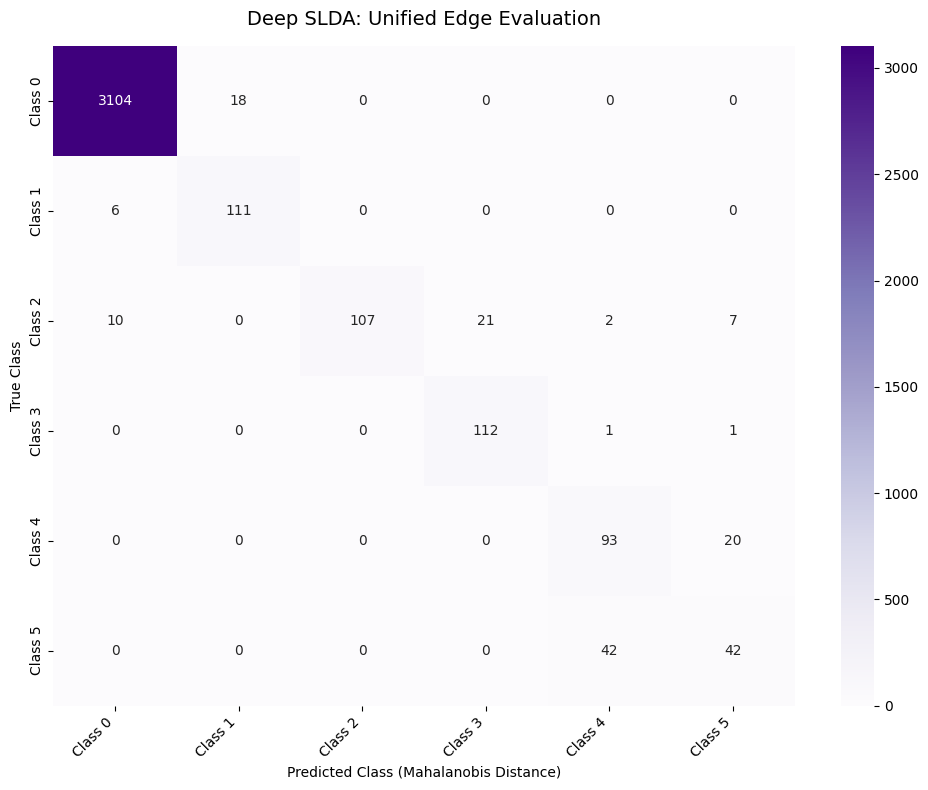


SLDA Classification Report (Zero Backpropagation Update)
              precision    recall  f1-score   support

     Class 0       0.99      0.99      0.99      3122
     Class 1       0.86      0.95      0.90       117
     Class 2       1.00      0.73      0.84       147
     Class 3       0.84      0.98      0.91       114
     Class 4       0.67      0.82      0.74       113
     Class 5       0.60      0.50      0.55        84

    accuracy                           0.97      3697
   macro avg       0.83      0.83      0.82      3697
weighted avg       0.97      0.97      0.96      3697



In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import ConcatDataset, DataLoader

def evaluate_slda(slda_model, backbone, loader_base, loader_novel, device='cuda'):
    backbone.eval()
    all_preds = []
    all_labels = []
    
    combined_dataset = ConcatDataset([loader_base.dataset, loader_novel.dataset])
    combined_loader = DataLoader(combined_dataset, batch_size=64, shuffle=False)
    
    print("\n Running Deep SLDA Inference on ALL test data...")
    
    with torch.no_grad():
        for inputs, labels in combined_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # Extract features using the frozen backbone
            features, _ = backbone(inputs)
            
            # Predict using the math-based SLDA classifier
            preds, _ = slda_model.predict(features)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # Generate robust class names based on actual unique labels found
    unique_labels = sorted(list(set(all_labels)))
    class_names = [f"Class {lbl}" for lbl in unique_labels]

    # Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Deep SLDA: Unified Edge Evaluation", fontsize=14, pad=15)
    plt.xlabel('Predicted Class (Mahalanobis Distance)')
    plt.ylabel('True Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Print Report
    print("\n" + "="*60)
    print("SLDA Classification Report (Zero Backpropagation Update)")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

# Run the evaluation
evaluate_slda(slda_classifier, meta_metric_model, base_test_loader, novel_test_loader, device=device)

In [14]:
import torch
import numpy as np

def enable_dropout(model):
    """Enables dropout layers during inference for MC Dropout"""
    for m in model.modules():
        if m.__class__.__name__.startswith('Dropout'):
            m.train()

def mc_dropout_inference(model, slda, dataloader, num_passes=5, uncertainty_threshold=0.2, device='cuda'):
    """
    Evaluates uncertainty using MC Dropout. 
    If the variance of the predictions exceeds the threshold, the movement is safely rejected.
    """
    model.eval()
    enable_dropout(model) # Turn ON dropout for Monte Carlo sampling
    
    total_samples = 0
    rejected_samples = 0
    accepted_correct = 0
    
    print(f"\n Running Medical-Grade MC Dropout (Passes: {num_passes}, Threshold: {uncertainty_threshold})")
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            batch_size = inputs.size(0)
            
            # Store predictions for the passes: Shape (num_passes, batch_size)
            pass_predictions = torch.zeros(num_passes, batch_size).to(device)
            
            for p in range(num_passes):
                features, _ = model(inputs)
                preds, _ = slda.predict(features)
                pass_predictions[p] = preds
                
            for i in range(batch_size):
                total_samples += 1
                true_label = labels[i].item()
                
                # Get the 5 predictions for this specific sample
                sample_preds = pass_predictions[:, i]
                
                # Calculate Variance as our Uncertainty Metric
                # If all passes predict the same class, variance is 0.0
                uncertainty = torch.var(sample_preds).item()
                
                # Majority vote for the final predicted class
                final_pred = torch.mode(sample_preds).values.item()
                
                if uncertainty > uncertainty_threshold:
                    rejected_samples += 1
                else:
                    if final_pred == true_label:
                        accepted_correct += 1
                        
    accepted_samples = total_samples - rejected_samples
    accuracy = (accepted_correct / accepted_samples) * 100 if accepted_samples > 0 else 0
    
    print("\n" + "="*50)
    print(" Uncertainty Quantification (MC Dropout) Report")
    print("="*50)
    print(f"Total Tested: {total_samples}")
    print(f"Rejected (Uncertain/High Variance): {rejected_samples} ({(rejected_samples/total_samples)*100:.2f}%)")
    print(f"Accepted (Confident): {accepted_samples} ({(accepted_samples/total_samples)*100:.2f}%)")
    print(f"Accuracy on Confident Samples: {accuracy:.2f}%")
    print("="*50)

# Run MC Dropout on the Unified Test Loader
mc_dropout_inference(meta_metric_model, slda_classifier, base_test_loader, num_passes=5, uncertainty_threshold=0.1, device=device)


 Running Medical-Grade MC Dropout (Passes: 5, Threshold: 0.1)

 Uncertainty Quantification (MC Dropout) Report
Total Tested: 3697
Rejected (Uncertain/High Variance): 236 (6.38%)
Accepted (Confident): 3461 (93.62%)
Accuracy on Confident Samples: 98.90%


In [15]:
import torch

def coral_loss(source_features, target_features):
    """
    Deep CORAL Loss: Aligns the second-order statistics (covariances) 
    of the Source domain (old session) and Target domain (new session).
    """
    d = source_features.size(1)
    
    # Source covariance
    source_mean = torch.mean(source_features, 0, keepdim=True)
    source_centered = source_features - source_mean
    source_cov = (source_centered.t() @ source_centered) / (source_features.size(0) - 1)
    
    # Target covariance
    target_mean = torch.mean(target_features, 0, keepdim=True)
    target_centered = target_features - target_mean
    target_cov = (target_centered.t() @ target_centered) / (target_features.size(0) - 1)
    
    # Frobenius norm squared
    loss = torch.sum(torch.pow(source_cov - target_cov, 2))
    loss = loss / (4 * d * d)
    
    return loss

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
import copy

class ShiftedEMGDataset(Dataset):
    """
    Simulates real-world Domain Shift (e.g., electrode displacement, sweat)
    by adding statistical noise and feature offsets to the original HD-sEMG data.
    """
    def __init__(self, original_dataset, shift_factor=0.3, noise_std=0.1):
        self.original_dataset = original_dataset
        self.shift_factor = shift_factor
        self.noise_std = noise_std

    def __len__(self):
        return len(self.original_dataset)

    def __getitem__(self, idx):
        x, y = self.original_dataset[idx]
        # Simulate electrode shift and impedance changes
        noise = torch.randn_like(x) * self.noise_std
        shifted_x = x + self.shift_factor + noise
        return shifted_x, y

print(" Generating Target Domain (Simulating Electrode Shift/Sweat)...")
# Create Target Domain (Shifted Data) from the Base Training Data
target_train_ds = ShiftedEMGDataset(base_train_ds, shift_factor=0.5, noise_std=0.2)
target_test_ds = ShiftedEMGDataset(base_test_ds, shift_factor=0.5, noise_std=0.2)

target_train_loader = DataLoader(target_train_ds, batch_size=64, shuffle=True)
target_test_loader = DataLoader(target_test_ds, batch_size=64, shuffle=False)
print(" Target Domain DataReady.")

 Generating Target Domain (Simulating Electrode Shift/Sweat)...
 Target Domain DataReady.


In [18]:
import torch.nn.functional as F
import torch.optim as optim

def train_domain_adaptation_fixed(model, original_model, source_loader, target_loader, epochs=10, lambda_coral=0.5, device='cuda'):
    """
    Fixed UDA Training Loop: Uses Knowledge Distillation (Anchor Loss) 
    to prevent Feature Collapse while aligning domains with CORAL.
    """
    model.to(device)
    original_model.to(device)
    original_model.eval() # Freeze the brilliant original model
    model.train()
    
    # Lower learning rate for fine-tuning
    optimizer = optim.Adam(model.parameters(), lr=0.0001) 
    
    print(" Starting FIXED Domain Adaptation (Anchored CORAL)...")
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        coral_epoch_loss = 0.0
        anchor_epoch_loss = 0.0
        
        for (src_x, _), (tgt_x, _) in zip(source_loader, target_loader):
            src_x, tgt_x = src_x.to(device), tgt_x.to(device)
            
            optimizer.zero_grad()
            
            # 1. Forward pass on the model being trained
            src_features, _ = model(src_x)
            tgt_features, _ = model(tgt_x)
            
            # 2. Get features from the frozen original model (The Anchor)
            with torch.no_grad():
                orig_src_features, _ = original_model(src_x)
                
            # 3. Anchor Loss: Don't forget how to classify! (MSE between old and new features)
            loss_anchor = F.mse_loss(src_features, orig_src_features)
            
            # 4. CORAL Loss: Align the domains
            loss_coral = coral_loss(src_features, tgt_features)
            
            # Total Loss: Balance memory (anchor) and adaptation (coral)
            total_loss = loss_anchor + (lambda_coral * loss_coral)
            
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += total_loss.item()
            coral_epoch_loss += loss_coral.item()
            anchor_epoch_loss += loss_anchor.item()
            
        print(f"Epoch [{epoch+1}/{epochs}] | Anchor: {anchor_epoch_loss:.4f} | CORAL: {coral_epoch_loss:.4f}")
        
    return model

# Reset the DOA backbone to a fresh copy
doa_backbone_fixed = copy.deepcopy(meta_metric_model)

# Run the fixed training
doa_backbone_fixed = train_domain_adaptation_fixed(
    doa_backbone_fixed, 
    meta_metric_model, 
    base_train_loader, 
    target_train_loader, 
    epochs=10, 
    lambda_coral=0.5, # Reduced weight to balance with Anchor
    device=device
)

def test_doa_vs_baseline(baseline_model, doa_model, slda, dataloader, device='cuda'):
    """
    تقوم هذه الدالة بمقارنة أداء الموديل الأساسي (بدون تكيف) 
    مع موديل الـ DOA (بعد التكيف) على بيانات الـ Target (المشوشة/المزاحة).
    """
    baseline_model.eval()
    doa_model.eval()

    baseline_correct = 0
    doa_correct = 0
    total = 0

    print("\n" + "="*60)
    print("  Comparing Baseline vs. DOA on Target Domain (Shifted Data)")
    print("="*60)

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)

            # 1. اختبار الموديل القديم (Baseline)
            emb_base, _ = baseline_model(x)
            preds_base, _ = slda.predict(emb_base)
            baseline_correct += (preds_base == y).sum().item()

            # 2. اختبار الموديل الجديد (DOA)
            emb_doa, _ = doa_model(x)
            preds_doa, _ = slda.predict(emb_doa)
            doa_correct += (preds_doa == y).sum().item()

            total += y.size(0)

    # حساب النسبة المئوية للدقة
    base_acc = (baseline_correct / total) * 100
    doa_acc = (doa_correct / total) * 100

    print(f"Total Test Samples (Target Domain): {total}")
    print(f"Baseline Model Accuracy (Without Adaptation): {base_acc:.2f}%")
    print(f"DOA Model Accuracy (With Anchored CORAL):     {doa_acc:.2f}%")
    print("="*60)
    
    if doa_acc > base_acc:
        print(" Domain Adaptation Successful! DOA model is more robust to noise/shift.")
    else:
        print(" DOA model did not outperform the baseline. Check hyperparameters.")

# Test again!
test_doa_vs_baseline(meta_metric_model, doa_backbone_fixed, slda_classifier, target_test_loader, device=device)

 Starting FIXED Domain Adaptation (Anchored CORAL)...
Epoch [1/10] | Anchor: 0.0289 | CORAL: 0.0002
Epoch [2/10] | Anchor: 0.0258 | CORAL: 0.0001
Epoch [3/10] | Anchor: 0.0231 | CORAL: 0.0001
Epoch [4/10] | Anchor: 0.0230 | CORAL: 0.0001
Epoch [5/10] | Anchor: 0.0223 | CORAL: 0.0001
Epoch [6/10] | Anchor: 0.0229 | CORAL: 0.0001
Epoch [7/10] | Anchor: 0.0197 | CORAL: 0.0002
Epoch [8/10] | Anchor: 0.0210 | CORAL: 0.0001
Epoch [9/10] | Anchor: 0.0180 | CORAL: 0.0001
Epoch [10/10] | Anchor: 0.0173 | CORAL: 0.0001

  Comparing Baseline vs. DOA on Target Domain (Shifted Data)
Total Test Samples (Target Domain): 3697
Baseline Model Accuracy (Without Adaptation): 92.07%
DOA Model Accuracy (With Anchored CORAL):     95.16%
 Domain Adaptation Successful! DOA model is more robust to noise/shift.


In [19]:
# ==========================================
# Save the Final Trained Model Weights
# ==========================================
import torch
import os


save_path = "trained_doa_backbone.pth"


torch.save(doa_backbone_fixed.state_dict(), save_path)

print(f" Success! Final model weights saved to: {save_path}")
print(" You can now download this file from Kaggle's /working directory to use in your live Edge hardware setup.")

 Success! Final model weights saved to: trained_doa_backbone.pth
 You can now download this file from Kaggle's /working directory to use in your live Edge hardware setup.
